In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv('../creditcard.csv')
print('dataset loaded successfully')
print('shape: ', df.shape)

dataset loaded successfully
shape:  (284807, 31)


In [9]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [10]:
print('NULL values in each col: ')
print(df.isnull().sum())
print('\nData Types: ')
print(df.dtypes)

NULL values in each col: 
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Data Types: 
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [11]:
print('Class Distribution')
print(df['Class'].value_counts())
print("\nPercentage")
print(df['Class'].value_counts(normalize=True) * 100)

Class Distribution
Class
0    284315
1       492
Name: count, dtype: int64

Percentage
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


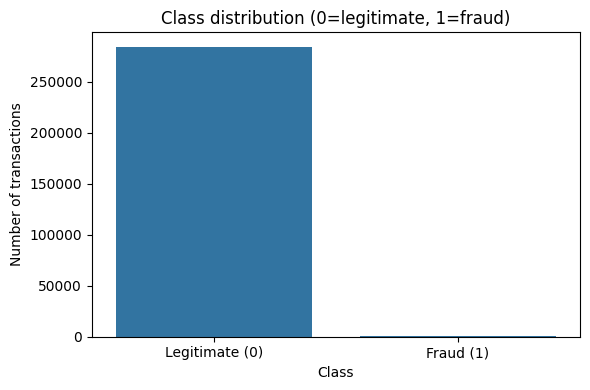

In [22]:
plt.figure(figsize = (6, 4))
sns.countplot(x = 'Class', data=df)
plt.title('Class distribution (0=legitimate, 1=fraud)')
plt.xticks([0, 1], ['Legitimate (0)', 'Fraud (1)'])
plt.ylabel('Number of transactions')
plt.tight_layout()
plt.savefig('../reports/class_distribution.png')
plt.show()

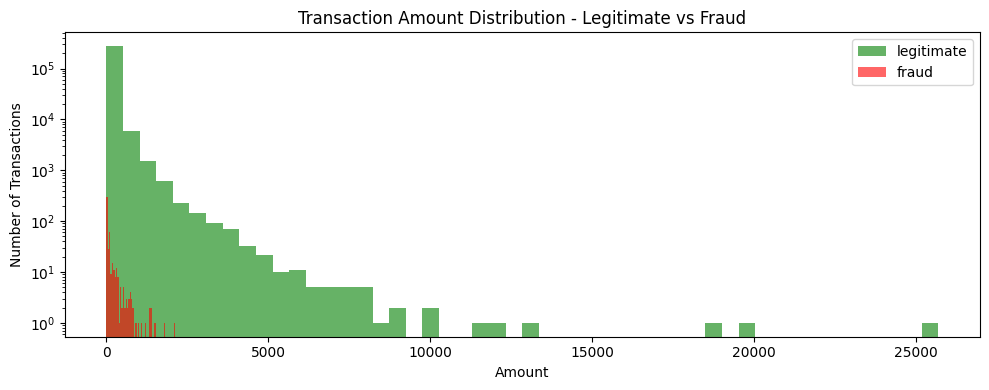

In [38]:
plt.figure(figsize = (10, 4))
plt.hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.6, label='legitimate', color='green')
plt.hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.6, label='fraud', color='red')
plt.title('Transaction Amount Distribution - Legitimate vs Fraud')
plt.xlabel('Amount')
plt.ylabel('Number of Transactions')
plt.legend()
plt.yscale('log')
plt.tight_layout()
plt.savefig('../reports/amount_distribution.png')
plt.show()

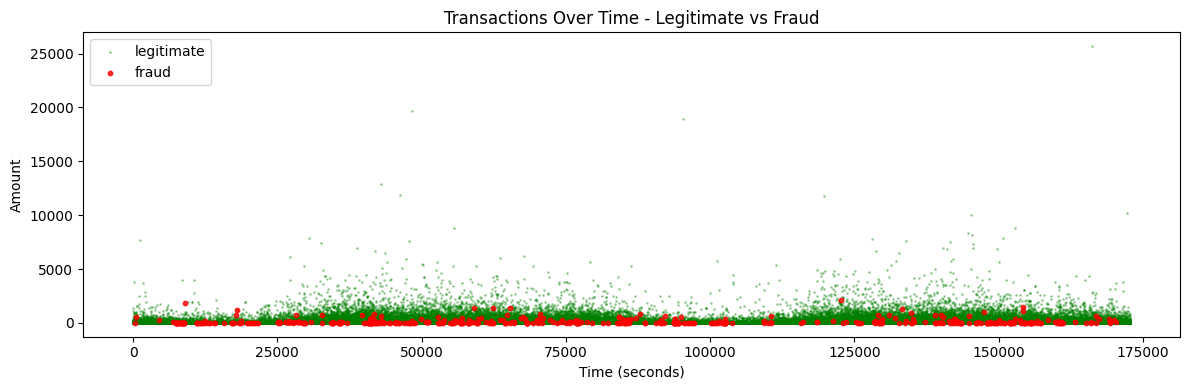

In [49]:
plt.figure(figsize= (12, 4))
plt.scatter(df[df['Class']==0]['Time'], 
           df[df['Class']==0]['Amount'],
           alpha=0.3, label='legitimate', s=1, color='green')

plt.scatter(df[df['Class']==1]['Time'], 
           df[df['Class']==1]['Amount'],
           alpha=0.8, label='fraud', s=10, color='red')

plt.title('Transactions Over Time - Legitimate vs Fraud')
plt.xlabel('Time (seconds)')
plt.ylabel('Amount')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/time_distribution.png')
plt.show()

In [51]:
print("Legitimate Transactions - Amount Stats:")
print(df[df['Class']==0]['Amount'].describe())

print("\nFraud Transactions - Amount Stats:")
print(df[df['Class']==1]['Amount'].describe())

Legitimate Transactions - Amount Stats:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

Fraud Transactions - Amount Stats:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


In [56]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x = df.drop('Class', axis=1)
y = df['Class']

print("Features shape:", x.shape)
print("Target shape:", y.shape)

X_train, X_test, Y_train, Y_test =  train_test_split(
    x, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("Fraud cases in training:", sum(Y_train))
print("Fraud cases in test:", sum(Y_test))

scaler = StandardScaler()


X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling complete!")
print("Sample values after scaling:", X_train[0][:5])

Features shape: (284807, 30)
Target shape: (284807,)
Training set size: (227845, 30)
Test set size: (56962, 30)
Fraud cases in training: 394
Fraud cases in test: 98
Scaling complete!
Sample values after scaling: [ 1.41158751  0.99337908 -0.45603659 -0.89405156 -0.46728372]
